In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 20

In [3]:
# We want to get the polygons and put them in random positions and orientations with area 1 / 8. We also want to set the
# perimeters and coms
# Then we want to rescale the perimeters to all be 1.4 or 1 (or some other distribution) setBiPerimeter
# Finally we can setPhi which involves finding the areas and rescaling them so that they sum to phi

In [4]:
numPolygons = 30
n = 32
nVals = [0, 1, 2, 3, 9, 4 ,5, 6, 20, 25, 35, 54]
i = 6
phi = 0.5
kappa = 3.65
stiffness = 1
modelType = "normal"
m = pcp.model(size = n * numPolygons, seed = i, modelType = modelType, stiffness = stiffness)
m.generateRandomPolygons(numPolygons, n, kappa = kappa, phi = phi)
m.updateRestEdgeLengths()
m.setMaxEdgeLength()

In [5]:
# Now that we have set the edge lengths, let's move the particles
# a bit:

In [6]:
positions = m.getPositions() + np.random.randn(m.getNumVertices() * 2) * 1e-3
positions += 1.0
positions %= 1.0
m.setPositions(positions)

In [7]:
m.getPositions()

array([0.41477541, 0.55226955, 0.4251758 , ..., 0.69613956, 0.32143697,
       0.69745022])

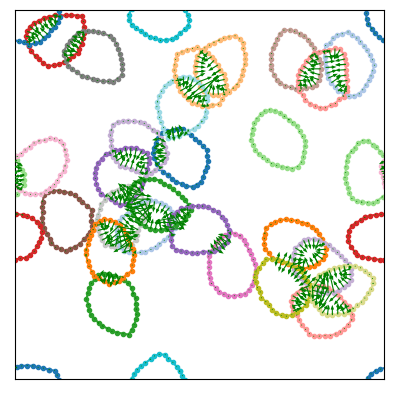

In [8]:
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0.01)
m.updateContacts()
m.updateOutersections()
m.updateForceEnergy()
m.updateAreas()
forceTest = m.getForces()
positions0 = m.getPositions()
m.updateAreas()
areas0 = m.getAreas()
fig, ax = plt.subplots()
artists2 = m.draw(ax = ax, forces = forceTest, arrowColor = 'g')

In [9]:
m.getForces()

array([-7.42737424e-05,  7.88852298e-06, -1.19550402e-03, ...,
        5.15306543e-04,  9.43783056e-05,  2.34613924e-05])

In [10]:
m.getEnergy()

0.1752913008004885